# Übung 4: Word Tokenization

Datensatz: `tweet_emotion_clean.parquet` – bereinigte Tweets mit Emotions-Label.

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

plt.rcParams["figure.figsize"] = (12, 5)

## 1 Daten laden

In [2]:
df = pl.read_parquet("../data/tweet_emotion_clean.parquet")
df.head()

content_clean,emotion
str,str
"""i know i was listenin to bad h…","""empty"""
"""layin n bed with a headache ug…","""sadness"""
"""funeral ceremonygloomy friday""","""sadness"""
"""wants to hang out with friends…","""enthusiasm"""
"""we want to trade with someone …","""neutral"""


## 2 Word Tokenization

Jeder Tweet wird an Leerzeichen aufgeteilt – jedes Wort wird ein eigenes Token.

In [3]:
df = df.with_columns(
    pl.col("content_clean").str.split(" ").alias("words")
)
df.select(["content_clean", "words"]).head(5)

content_clean,words
str,list[str]
"""i know i was listenin to bad h…","[""i"", ""know"", … ""part""]"
"""layin n bed with a headache ug…","[""layin"", ""n"", … ""call""]"
"""funeral ceremonygloomy friday""","[""funeral"", ""ceremonygloomy"", ""friday""]"
"""wants to hang out with friends…","[""wants"", ""to"", … ""soon""]"
"""we want to trade with someone …","[""we"", ""want"", … ""will""]"


## 3 Word Types und Word Instances

In [4]:

# Alle Wörter aus allen Tweets in eine flache Liste
all_words = (
    df.explode("words")
    .filter(pl.col("words").is_not_null() & (pl.col("words") != ""))
    ["words"]
    .to_list()
)

word_counts = pd.Series(all_words).value_counts().reset_index()
word_counts.columns = ["word", "count"]

print(f"Word Instances (N): {len(all_words):,}")
print(f"Word Types (|V|):   {len(word_counts):,}")
word_counts.head(10)


Word Instances (N): 494,638
Word Types (|V|):   34,151


,word,count
0,i,18990
1,to,14330
2,the,12850
3,a,9629
4,my,7972
5,and,7315
6,you,6956
7,it,5801
8,is,5677
9,in,5370


## 4 Stop Words entfernen

Wörter wie "the", "i", "a" kommen sehr häufig vor, sagen aber nichts über die Emotion aus.

In [5]:
stop_words = set(stopwords.words("english"))

filtered_words = [w for w in all_words if w not in stop_words and len(w) > 1]

word_counts_filtered = pd.Series(filtered_words).value_counts().reset_index()
word_counts_filtered.columns = ["word", "count"]

print(f"Word Instances nach Stop-Word-Entfernung: {len(filtered_words):,}")
print(f"Word Types nach Stop-Word-Entfernung:     {len(word_counts_filtered):,}")
word_counts_filtered.head(10)

Word Instances nach Stop-Word-Entfernung: 282,106
Word Types nach Stop-Word-Entfernung:     33,989


,word,count
0,im,4370
1,day,2990
2,good,2243
3,get,1999
4,like,1928
5,go,1796
6,dont,1700
7,got,1614
8,love,1602
9,today,1579


## 5 Visualisierung – Top 20 häufigste Wörter

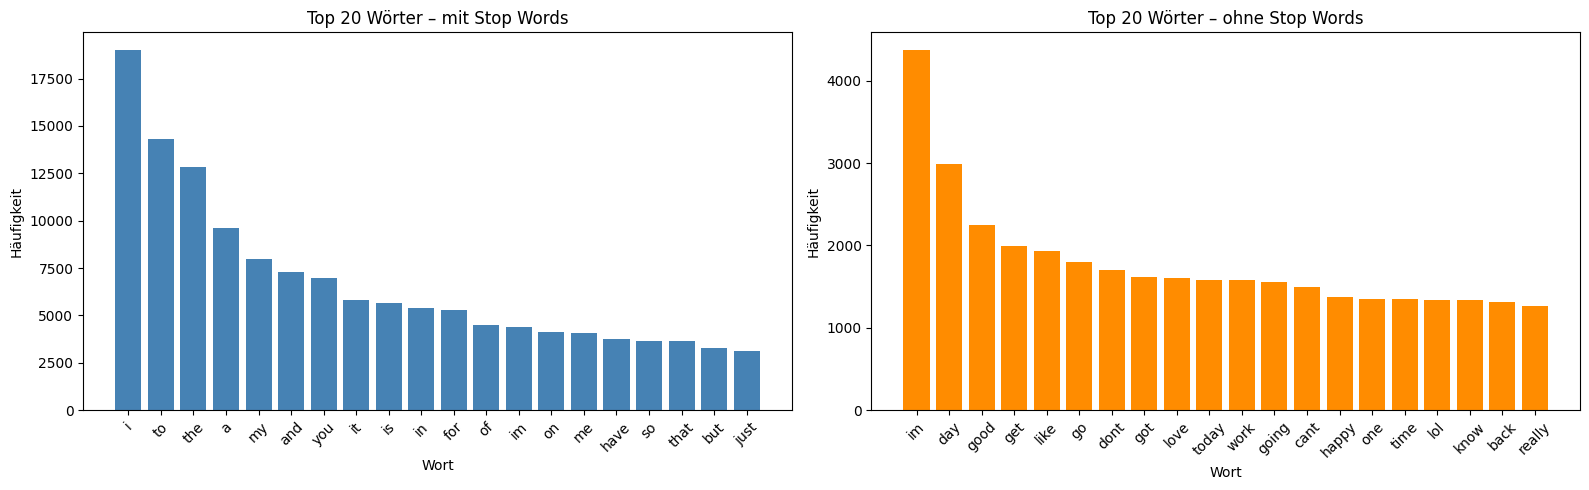

In [6]:
top_n = 20
top_words = word_counts_filtered.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mit Stop Words
top_raw = word_counts.head(top_n)
axes[0].bar(top_raw["word"], top_raw["count"], color="steelblue")
axes[0].set_title(f"Top {top_n} Wörter – mit Stop Words")
axes[0].set_xlabel("Wort")
axes[0].set_ylabel("Häufigkeit")
axes[0].tick_params(axis="x", rotation=45)

# Ohne Stop Words
axes[1].bar(top_words["word"], top_words["count"], color="darkorange")
axes[1].set_title(f"Top {top_n} Wörter – ohne Stop Words")
axes[1].set_xlabel("Wort")
axes[1].set_ylabel("Häufigkeit")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6 Erkenntnisse

- **Mit Stop Words** dominieren bedeutungslose Wörter wie "i", "the", "a" die Liste.
- **Ohne Stop Words** tauchen emotionsrelevante Wörter auf wie "feel", "love", "good", "day".
- Word Tokenization allein reicht für das Klassifikationsproblem nicht aus – Varianten desselben Wortes ("feel", "feeling", "feels") werden als verschiedene Token gezählt.
- Subword-Tokenization (z. B. BPE) kann dieses Problem lösen → Aufgabe 5.